# QuickScorer benchmark

How the CPU-runnable conifer backends scale with the size of the ensemble, and
how to tune the block-wise QuickScorer (BWQS) block shape for this machine.

* **Benchmark** — µs / sample against ensemble size, one panel per tree depth,
  with a marker at the ensemble size whose QuickScorer data structures fill L3.
* **Hyperparameter optimization** — sweep (tau, delta) for the `cpp` backend's
  BWQS traversal and pick the fastest block shape.

QuickScorer: https://doi.org/10.1145/2766462.2767733. The compiled backends need
the Xilinx `ap_` and nlohmann JSON headers (`XILINX_AP_INCLUDE`, `JSON_ROOT`).
For the correctness checks between backends see `quickscorer_cpu_bench.py`.

In [1]:
from sklearn.datasets import make_hastie_10_2
from sklearn.ensemble import GradientBoostingClassifier
import conifer
import copy
import datetime
import glob
import logging
import os
import shutil
import sys
import time
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker
%matplotlib inline

logging.basicConfig(stream=sys.stdout, level=logging.WARNING)

# the script directory when run as a .py, the working directory in a notebook
try:
    OUTPUT_DIR = os.path.dirname(os.path.abspath(__file__))
except NameError:
    OUTPUT_DIR = os.getcwd()

## Configuration

Everything the benchmark does is driven from this cell.

In [2]:
# backends to benchmark, in plot order. Available:
#   'sklearn', 'python/treewalk', 'python/quickscorer', 'python/bwqs',
#   'cpp/treewalk', 'cpp/quickscorer', 'cpp/bwqs'
# ('python/treewalk' is a pure-python node loop: expect it to be very slow)
# the current configuration takes around 11 minutes on a single AMD Zen5 CPU core at 5GHz.
BACKENDS = ['python/quickscorer', 'python/bwqs', 'cpp/treewalk', 'cpp/quickscorer', 'cpp/bwqs']

SIZES = [8, 16, 32, 64, 128, 16384, 65536]   # ensemble sizes (trees), also the x ticks
DEPTHS = [4, 6]             # tree depths, one plot panel each
N_SAMPLES = 1000               # samples scored per timing
REPEATS = 2                    # timings are best-of-N

LEARNING_RATE = 0.1            # at 1.0 the hastie residuals vanish and the late
                               # trees degenerate to stumps, skewing the sweep
PRECISION = 'ap_fixed<18,8>'   # for the compiled backends
PY_TAU, PY_DELTA = 128, 4096   # python bwqs: numpy scores delta samples at once
CPP_TAU, CPP_DELTA = 1024, 16   # cpp bwqs: the cpp loop scores one sample at a time

L3_OVERRIDE = None             # bytes, to override the autodetected L3

## This machine's L3

Many CPUs have several L3 caches that are **not** unified (multi-CCX AMD parts,
hybrid Intel parts), so the size the vendor advertises is their sum while a
single-threaded run only ever sees one of them. Estimate against the domain this
thread can actually run on.

In [3]:
def _parse_cpu_list(s):
    '''"0-3,12-15" -> frozenset({0,1,2,3,12,13,14,15})'''
    cpus = set()
    for part in s.split(','):
        lo, _, hi = part.partition('-')
        cpus.update(range(int(lo), int(hi or lo) + 1))
    return frozenset(cpus)


def l3_domains():
    '''[(size_bytes, cpus, cpu_list_string)] for every distinct L3, largest first.'''
    seen = {}
    for p in sorted(glob.glob('/sys/devices/system/cpu/cpu*/cache/index*')):
        try:
            if int(open(f'{p}/level').read()) != 3:
                continue
            cpu_list = open(f'{p}/shared_cpu_list').read().strip()
            raw = open(f'{p}/size').read().strip()
        except (OSError, ValueError):
            continue
        size = int(raw[:-1]) * {'K': 1024, 'M': 1024**2, 'G': 1024**3}[raw[-1]]
        seen[_parse_cpu_list(cpu_list)] = (size, cpu_list)
    return sorted(((sz, cpus, s) for cpus, (sz, s) in seen.items()), key=lambda d: -d[0])


domains = l3_domains()
if L3_OVERRIDE:
    L3 = L3_OVERRIDE
elif domains:
    allowed = os.sched_getaffinity(0)
    reachable = [d for d in domains if d[1] & allowed] or domains
    pivot = min(min(cpus) for _, cpus, _ in reachable)  # lowest core we may run on
    L3 = next(sz for sz, cpus, _ in reachable if pivot in cpus)
else:
    L3 = 24 * 1024**2  # no sysfs (not Linux): guess

for sz, _, cpu_list in domains:
    print(f'L3 {sz / 1024**2:5.0f} MB  cpus {cpu_list}')
if len(domains) > 1:
    print(f'\n{len(domains)} L3 domains, not unified: the advertised '
          f'{sum(sz for sz, _, _ in domains) / 1024**2:.0f} MB is their sum, but this '
          'run sees only one. Pin the process to make it reproducible, e.g. taskset -c 0-3')
print(f'\nusing L3 = {L3 / 1024**2:.2f} MB')

L3    16 MB  cpus 0-3,12-15
L3     8 MB  cpus 4-11,16-23

2 L3 domains, not unified: the advertised 24 MB is their sum, but this run sees only one. Pin the process to make it reproducible, e.g. taskset -c 0-3

using L3 = 16.00 MB


### Force running on the same CPU core

In [4]:
import os
import subprocess

CPU = 1
PID = os.getpid()

subprocess.run(["taskset", "-cp", str(CPU), str(PID)], check=True)

print(f"Jupyter kernel {PID} pinned to CPU {CPU}")

pid 2907411's current affinity list: 0-23
pid 2907411's new affinity list: 1
Jupyter kernel 2907411 pinned to CPU 1


## Dataset and models

In [5]:
# Make a random dataset from sklearn 'hastie'
X, y = make_hastie_10_2(random_state=0)
X_train, y_train = X[:2000], y[:2000]
X_bench = np.resize(X[2000:], (N_SAMPLES, X.shape[1]))  # test set, repeated to N_SAMPLES

stamp = int(datetime.datetime.now().timestamp())


def sub_ensemble(clf, n):
    '''A trained GradientBoosting model restricted to its first n trees. Boosting
    is additive, so the first n stages are themselves a valid n-tree model: one
    fit per depth covers every ensemble size.'''
    sub = copy.copy(clf)
    sub.estimators_ = clf.estimators_[:n]
    sub.n_estimators = n
    return sub


trained = {}
for depth in DEPTHS:
    print(f'training {max(SIZES)} trees at depth {depth}...', flush=True)
    trained[depth] = GradientBoostingClassifier(
        n_estimators=max(SIZES), learning_rate=LEARNING_RATE,
        max_depth=depth, random_state=0).fit(X_train, y_train)

training 65536 trees at depth 4...
training 65536 trees at depth 6...


## Timing and plotting helpers

In [6]:
def time_us(fn, X, repeats=REPEATS):
    '''Best-of-N wall time per sample, in microseconds'''
    best = float('inf')
    for _ in range(repeats):
        t0 = time.perf_counter()
        fn(X)
        best = min(best, time.perf_counter() - t0)
    return best / len(X) * 1e6


def plot_vs_size(results, sizes, *, ax=None, logx=True, logy=True,
                 xlabel='ensemble size (trees)', ylabel=None, title=None,
                 figsize=(10, 6.5)):
    '''One line per series of `results` ({label: [y per size]}, insertion order is
    the legend order) against ensemble size. Log-log by default, ticked at the
    actual `sizes` rather than at decade powers. Returns the Axes.'''
    if ax is None:
        _, ax = plt.subplots(figsize=figsize)
    for label, ys in results.items():
        if not np.all(np.isnan(ys)):
            ax.plot(sizes, ys, label=label, linewidth=2, marker='o', markersize=5)
    if logx:
        ax.set_xscale('log')
    if logy:
        ax.set_yscale('log')
    ax.grid(True, which='both', alpha=0.3)
    ax.set_xticks(sizes)
    ax.get_xaxis().set_major_formatter(matplotlib.ticker.ScalarFormatter())
    ax.get_xaxis().set_minor_formatter(matplotlib.ticker.NullFormatter())
    ax.set_xlabel(xlabel)
    if ylabel:
        ax.set_ylabel(ylabel)
    if title:
        ax.set_title(title)
    ax.legend()
    return ax


def mark_l3(ax, n_trees, sizes, label='working set = L3'):
    '''Vertical marker at `n_trees`, but only if it lands inside the plotted range:
    an off-range axvline would stretch the log x-axis and squash the data.'''
    if not (min(sizes) <= n_trees <= max(sizes)):
        return False
    ax.axvline(n_trees, color='grey', linewidth=1, linestyle='--')
    ax.text(n_trees * 1.03, 0.97, label, transform=ax.get_xaxis_transform(),
            va='top', fontsize=8, color='grey')
    return True

## The backends

One builder per backend label: it takes a trained model and an output directory,
and returns a callable that scores an array. Add a backend to the benchmark by
adding its label to `BACKENDS`.

In [7]:
def python_scorer(clf, algorithm):
    cfg = conifer.backends.python.auto_config()
    cfg.update({'Algorithm': algorithm, 'Tau': PY_TAU, 'Delta': PY_DELTA})
    return conifer.converters.convert_from_sklearn(clf, cfg).decision_function


def compile_model(backend, clf, out_dir, **extra):
    '''Convert and compile clf for one of the compiled backends.'''
    cfg = backend.auto_config()
    cfg.update({'OutputDir': out_dir, 'Precision': PRECISION}, **extra)
    model = conifer.converters.convert_from_sklearn(clf, cfg)
    model.compile()
    return model


def cpp_scorer(clf, out_dir, algorithm, **extra):
    '''Compile clf for the cpp backend and score with one of its traversals.'''
    model = compile_model(conifer.backends.cpp, clf, out_dir, **extra)
    return lambda X: model.decision_function(X, algorithm=algorithm)


def set_block_shape(model, tau, delta):
    '''Point a compiled cpp model at a new (tau, delta) BWQS block shape. They are
    runtime arguments of the bridge, so the next scoring call rebuilds only the
    traversal data structures and not the machine code: one build serves a whole
    sweep, and the timings stay directly comparable.'''
    model.config.tau, model.config.delta = tau, delta


BUILDERS = {
    'sklearn':            lambda clf, d: clf.decision_function,
    'python/treewalk':    lambda clf, d: python_scorer(clf, 'treewalk'),
    'python/quickscorer': lambda clf, d: python_scorer(clf, 'quickscorer'),
    'python/bwqs':        lambda clf, d: python_scorer(clf, 'blockwise-quickscorer'),
    'cpp/treewalk':       lambda clf, d: cpp_scorer(clf, d, 'treewalk'),
    'cpp/quickscorer':    lambda clf, d: cpp_scorer(clf, d, 'quickscorer'),
    'cpp/bwqs':           lambda clf, d: cpp_scorer(clf, d, 'blockwise-quickscorer',
                                                    Tau=CPP_TAU, Delta=CPP_DELTA),
}
unknown = set(BACKENDS) - set(BUILDERS)
assert not unknown, f'unknown backend(s) {unknown}, expected some of {list(BUILDERS)}'

## QuickScorer structures vs L3

QuickScorer keeps no (n_samples x n_trees) bitvector matrix — the read-only
structures of Table 1 of the paper *are* its working set, reused for every
sample. Plain QS therefore starts missing L3 around the tree counts below, which
is where BWQS, holding one tau-tree block at a time, begins to pay off.

In [8]:
bytes_per_tree = {}  # depth -> QuickScorer structure bytes per tree
n_probe = min(max(SIZES), 64)  # the per-tree size is ~constant: a small probe suffices
for depth in DEPTHS:
    d = f'prj_{stamp}_probe_{depth}'
    try:
        model = compile_model(conifer.backends.cpp, sub_ensemble(trained[depth], n_probe), d)
        bytes_per_tree[depth] = model.nbytes() / n_probe
    except Exception as e:
        print(f'the cpp backend is unavailable, skipping the L3 estimate ({e})')
        break
    finally:
        shutil.rmtree(d, ignore_errors=True)

if bytes_per_tree:
    print(f'QuickScorer structures, probed on {n_probe} trees (L3 = {L3 / 1024**2:.2f} MB)\n')
    print(f'{"depth":>6s} {"bytes/tree":>12s} {"trees to fill L3":>18s}')
    for depth, bpt in bytes_per_tree.items():
        print(f'{depth:6d} {bpt:12.0f} {L3 / bpt:18.0f}')

In file included from /home/theayos/miniconda3/envs/opl-conifer-tutorial/include/python3.13/Python.h:14,
                 from /home/theayos/miniconda3/envs/opl-conifer-tutorial/lib/python3.13/site-packages/pybind11/include/pybind11/conduit/wrap_include_python_h.h:44,
                 from /home/theayos/miniconda3/envs/opl-conifer-tutorial/lib/python3.13/site-packages/pybind11/include/pybind11/detail/common.h:12,
                 from /home/theayos/miniconda3/envs/opl-conifer-tutorial/lib/python3.13/site-packages/pybind11/include/pybind11/attr.h:13,
                 from /home/theayos/miniconda3/envs/opl-conifer-tutorial/lib/python3.13/site-packages/pybind11/include/pybind11/detail/class.h:12,
                 from /home/theayos/miniconda3/envs/opl-conifer-tutorial/lib/python3.13/site-packages/pybind11/include/pybind11/pybind11.h:12,
                 from bridge.cpp:2:
/home/theayos/miniconda3/envs/opl-conifer-tutorial/include/python3.13/pyconfig.h:1964:9: warning: ‘_POSIX_C_SOURCE�� r

QuickScorer structures, probed on 64 trees (L3 = 16.00 MB)

 depth   bytes/tree   trees to fill L3
     4          311              53881
     6         1165              14396


## Benchmark — µs / sample vs ensemble size

In [9]:
bench = {depth: {label: [] for label in BACKENDS} for depth in DEPTHS}
for depth in DEPTHS:
    print(f'\ndepth {depth}, {N_SAMPLES} samples   µs / sample')
    print(f'{"trees":>6s} ' + ' '.join(f'{label:>20s}' for label in BACKENDS))
    for n in SIZES:
        sub = sub_ensemble(trained[depth], n)
        row = f'{n:6d} '
        for label in BACKENDS:
            d = f'prj_{stamp}_{label.replace("/", "_")}_{depth}_{n}'
            try:
                t = time_us(BUILDERS[label](sub, d), X_bench)
            except Exception as e:
                print(f'{label} failed at depth {depth}, {n} trees: {e}')
                t = np.nan
            finally:
                shutil.rmtree(d, ignore_errors=True)
            bench[depth][label].append(t)
            row += f'{t:20.2f}'
        print(row, flush=True)


depth 4, 1000 samples   µs / sample
 trees   python/quickscorer          python/bwqs         cpp/treewalk      cpp/quickscorer             cpp/bwqs


In file included from /home/theayos/miniconda3/envs/opl-conifer-tutorial/include/python3.13/Python.h:14,
                 from /home/theayos/miniconda3/envs/opl-conifer-tutorial/lib/python3.13/site-packages/pybind11/include/pybind11/conduit/wrap_include_python_h.h:44,
                 from /home/theayos/miniconda3/envs/opl-conifer-tutorial/lib/python3.13/site-packages/pybind11/include/pybind11/detail/common.h:12,
                 from /home/theayos/miniconda3/envs/opl-conifer-tutorial/lib/python3.13/site-packages/pybind11/include/pybind11/attr.h:13,
                 from /home/theayos/miniconda3/envs/opl-conifer-tutorial/lib/python3.13/site-packages/pybind11/include/pybind11/detail/class.h:12,
                 from /home/theayos/miniconda3/envs/opl-conifer-tutorial/lib/python3.13/site-packages/pybind11/include/pybind11/pybind11.h:12,
                 from bridge.cpp:2:
/home/theayos/miniconda3/envs/opl-conifer-tutorial/include/python3.13/pyconfig.h:1964:9: warning: ‘_POSIX_C_SOURCE�� r

     8                 0.97                0.94                3.62                0.33                0.33


In file included from /home/theayos/miniconda3/envs/opl-conifer-tutorial/include/python3.13/Python.h:14,
                 from /home/theayos/miniconda3/envs/opl-conifer-tutorial/lib/python3.13/site-packages/pybind11/include/pybind11/conduit/wrap_include_python_h.h:44,
                 from /home/theayos/miniconda3/envs/opl-conifer-tutorial/lib/python3.13/site-packages/pybind11/include/pybind11/detail/common.h:12,
                 from /home/theayos/miniconda3/envs/opl-conifer-tutorial/lib/python3.13/site-packages/pybind11/include/pybind11/attr.h:13,
                 from /home/theayos/miniconda3/envs/opl-conifer-tutorial/lib/python3.13/site-packages/pybind11/include/pybind11/detail/class.h:12,
                 from /home/theayos/miniconda3/envs/opl-conifer-tutorial/lib/python3.13/site-packages/pybind11/include/pybind11/pybind11.h:12,
                 from bridge.cpp:2:
/home/theayos/miniconda3/envs/opl-conifer-tutorial/include/python3.13/pyconfig.h:1964:9: warning: ‘_POSIX_C_SOURCE�� r

    16                 1.85                1.80                5.97                0.42                0.42


...

   128                44.18               44.22               61.42                4.04                4.03


In file included from /home/theayos/miniconda3/envs/opl-conifer-tutorial/include/python3.13/Python.h:14,
                 from /home/theayos/miniconda3/envs/opl-conifer-tutorial/lib/python3.13/site-packages/pybind11/include/pybind11/conduit/wrap_include_python_h.h:44,
                 from /home/theayos/miniconda3/envs/opl-conifer-tutorial/lib/python3.13/site-packages/pybind11/include/pybind11/detail/common.h:12,
                 from /home/theayos/miniconda3/envs/opl-conifer-tutorial/lib/python3.13/site-packages/pybind11/include/pybind11/attr.h:13,
                 from /home/theayos/miniconda3/envs/opl-conifer-tutorial/lib/python3.13/site-packages/pybind11/include/pybind11/detail/class.h:12,
                 from /home/theayos/miniconda3/envs/opl-conifer-tutorial/lib/python3.13/site-packages/pybind11/include/pybind11/pybind11.h:12,
                 from bridge.cpp:2:
/home/theayos/miniconda3/envs/opl-conifer-tutorial/include/python3.13/pyconfig.h:1964:9: warning: ‘_POSIX_C_SOURCE�� r

 16384              1225.16              746.07              956.61              115.02              104.17


In file included from /home/theayos/miniconda3/envs/opl-conifer-tutorial/include/python3.13/Python.h:14,
                 from /home/theayos/miniconda3/envs/opl-conifer-tutorial/lib/python3.13/site-packages/pybind11/include/pybind11/conduit/wrap_include_python_h.h:44,
                 from /home/theayos/miniconda3/envs/opl-conifer-tutorial/lib/python3.13/site-packages/pybind11/include/pybind11/detail/common.h:12,
                 from /home/theayos/miniconda3/envs/opl-conifer-tutorial/lib/python3.13/site-packages/pybind11/include/pybind11/attr.h:13,
                 from /home/theayos/miniconda3/envs/opl-conifer-tutorial/lib/python3.13/site-packages/pybind11/include/pybind11/detail/class.h:12,
                 from /home/theayos/miniconda3/envs/opl-conifer-tutorial/lib/python3.13/site-packages/pybind11/include/pybind11/pybind11.h:12,
                 from bridge.cpp:2:
/home/theayos/miniconda3/envs/opl-conifer-tutorial/include/python3.13/pyconfig.h:1964:9: warning: ‘_POSIX_C_SOURCE�� r

 65536              2459.22              958.44             3179.15              548.96              322.91


wrote /home/theayos/code/OPL/bdt-aie-openlab/conifer/examples/quickscorer_benchmark_vs_size.png


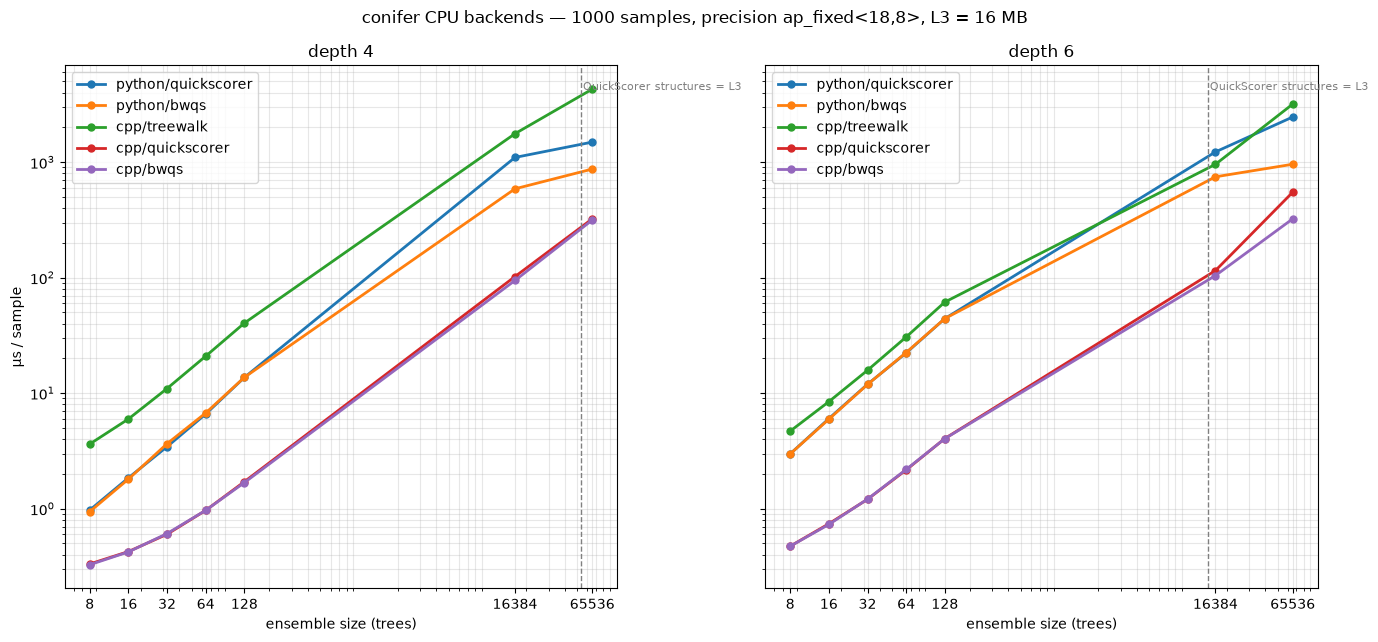

In [10]:
fig, axes = plt.subplots(1, len(DEPTHS), figsize=(7 * len(DEPTHS), 6.5),
                         sharey=True, squeeze=False)
for ax, depth in zip(axes[0], DEPTHS):
    plot_vs_size(bench[depth], SIZES, ax=ax, title=f'depth {depth}')
    if depth in bytes_per_tree:
        n_l3 = L3 / bytes_per_tree[depth]
        if not mark_l3(ax, n_l3, SIZES, 'QuickScorer structures = L3'):
            print(f'depth {depth}: the QuickScorer structures reach L3 at ~{n_l3:.0f} trees, '
                  f'off the plotted {min(SIZES)}..{max(SIZES)} range')
axes[0][0].set_ylabel('µs / sample')
fig.suptitle(f'conifer CPU backends — {N_SAMPLES} samples, precision {PRECISION}, '
             f'L3 = {L3 / 1024**2:.0f} MB')
fig.tight_layout()
out = os.path.join(OUTPUT_DIR, 'quickscorer_benchmark_vs_size.png')
fig.savefig(out, dpi=200, bbox_inches='tight')
print(f'wrote {out}')

### Save the results

These runs are slow, so keep every measured number in one tidy CSV. To replot
without re-measuring:

```python
df = pd.read_csv('quickscorer_benchmark_results.csv')
panel = df[df.depth == 5]
series = {s: g.sort_values('n_trees')['value'].tolist()
          for s, g in panel.groupby('series', sort=False)}
plot_vs_size(series, sorted(panel['n_trees'].unique()))
```

In [11]:
results = pd.DataFrame(
    [('us_per_sample', depth, label, n, v)
     for depth in DEPTHS for label in BACKENDS
     for n, v in zip(SIZES, bench[depth][label])],
    columns=['metric', 'depth', 'series', 'n_trees', 'value'])
results.attrs['params'] = {
    'sizes': SIZES, 'depths': DEPTHS, 'n_samples': N_SAMPLES, 'repeats': REPEATS,
    'learning_rate': LEARNING_RATE, 'precision': PRECISION, 'L3_bytes': int(L3),
    'py_block': (PY_TAU, PY_DELTA), 'cpp_block': (CPP_TAU, CPP_DELTA), 'stamp': stamp,
}
out = os.path.join(OUTPUT_DIR, 'quickscorer_benchmark_results.csv')
results.to_csv(out, index=False)
print(f'wrote {out} ({len(results)} rows), params: {results.attrs["params"]}')
results

wrote /home/theayos/code/OPL/bdt-aie-openlab/conifer/examples/quickscorer_benchmark_results.csv (70 rows), params: {'sizes': [8, 16, 32, 64, 128, 16384, 65536], 'depths': [4, 6], 'n_samples': 1000, 'repeats': 2, 'learning_rate': 0.1, 'precision': 'ap_fixed<18,8>', 'L3_bytes': 16777216, 'py_block': (128, 4096), 'cpp_block': (1024, 16), 'stamp': 1787601695}


,metric,depth,series,n_trees,value
0,us_per_sample,4,python/quickscorer,8,0.971779
1,us_per_sample,4,python/quickscorer,16,1.845729
2,us_per_sample,4,python/quickscorer,32,3.438166
3,us_per_sample,4,python/quickscorer,64,6.592764
4,us_per_sample,4,python/quickscorer,128,13.664255
...,...,...,...,...,...
65,us_per_sample,6,cpp/bwqs,32,1.208708
66,us_per_sample,6,cpp/bwqs,64,2.183347
67,us_per_sample,6,cpp/bwqs,128,4.034913
68,us_per_sample,6,cpp/bwqs,16384,104.174329


# BWQS Hyperparameter optimization (tau, delta)

tau (trees per block) and delta (samples per block) trade the size of the live
working set against the bookkeeping of revisiting each block. The best pair is
specific to the ensemble and to the machine (cf. Table 4 of the paper), so sweep
it. Because tau and delta are runtime arguments of the compiled bridge, the whole
grid runs on a **single** compiled binary.

In [12]:
HYPEROPT_DEPTH, HYPEROPT_N = max(DEPTHS), max(SIZES)


def _pow2(hi, lo=1):
    out, v = [], lo
    while v <= hi:
        out.append(v)
        v *= 2
    return out


TAUS = _pow2(HYPEROPT_N)          # up to the whole ensemble in one block
DELTAS = _pow2(N_SAMPLES, lo=4)   # up to all the samples in one pass

grid = np.full((len(TAUS), len(DELTAS)), np.nan)  # µs / sample
qs_baseline = np.nan
d = f'prj_{stamp}_hyperopt'
try:
    model = compile_model(conifer.backends.cpp,
                          sub_ensemble(trained[HYPEROPT_DEPTH], HYPEROPT_N), d)
    # plain QS: the whole ensemble in one block, all the samples in one pass
    qs_baseline = time_us(lambda X: model.decision_function(X, algorithm='quickscorer'), X_bench)
    bwqs = lambda X: model.decision_function(X, algorithm='blockwise-quickscorer')

    print(f'{HYPEROPT_N} trees, depth {HYPEROPT_DEPTH}, {N_SAMPLES} samples   µs / sample')
    print(f'{"tau/delta":>9s} ' + ' '.join(f'{delta:>7d}' for delta in DELTAS))
    for i, tau in enumerate(TAUS):
        for j, delta in enumerate(DELTAS):
            set_block_shape(model, tau, delta)
            grid[i, j] = time_us(bwqs, X_bench)
        print(f'{tau:9d} ' + ' '.join(f'{v:7.2f}' for v in grid[i]), flush=True)
finally:
    shutil.rmtree(d, ignore_errors=True)

bi, bj = np.unravel_index(np.nanargmin(grid), grid.shape)
best_tau, best_delta, best_us = TAUS[bi], DELTAS[bj], grid[bi, bj]
# NB on a small ensemble the whole thing already fits in cache, so blocking only
# adds bookkeeping and the best block shape can be slower than plain QS
print(f'\nplain QS : {qs_baseline:7.2f} µs / sample')
print(f'best BWQS: {best_us:7.2f} µs / sample at tau={best_tau}, delta={best_delta} '
      f'({qs_baseline / best_us:.2f}x vs plain QS)')

In file included from /home/theayos/miniconda3/envs/opl-conifer-tutorial/include/python3.13/Python.h:14,
                 from /home/theayos/miniconda3/envs/opl-conifer-tutorial/lib/python3.13/site-packages/pybind11/include/pybind11/conduit/wrap_include_python_h.h:44,
                 from /home/theayos/miniconda3/envs/opl-conifer-tutorial/lib/python3.13/site-packages/pybind11/include/pybind11/detail/common.h:12,
                 from /home/theayos/miniconda3/envs/opl-conifer-tutorial/lib/python3.13/site-packages/pybind11/include/pybind11/attr.h:13,
                 from /home/theayos/miniconda3/envs/opl-conifer-tutorial/lib/python3.13/site-packages/pybind11/include/pybind11/detail/class.h:12,
                 from /home/theayos/miniconda3/envs/opl-conifer-tutorial/lib/python3.13/site-packages/pybind11/include/pybind11/pybind11.h:12,
                 from bridge.cpp:2:
/home/theayos/miniconda3/envs/opl-conifer-tutorial/include/python3.13/pyconfig.h:1964:9: warning: ‘_POSIX_C_SOURCE�� r

65536 trees, depth 6, 1000 samples   µs / sample
tau/delta       4       8      16      32      64     128     256     512
        1  919.52  951.32  930.41  921.83  913.32  909.62  911.19  908.88
        2  644.77  656.87  644.21  636.09  629.86  627.81  627.46  628.74
        4  485.74  492.20  487.81  486.70  523.72  480.42  478.58  480.33
        8  411.03  401.56  399.38  396.78  395.42  395.14  396.52  395.51
       16  361.21  356.06  354.05  352.79  353.76  354.45  352.92  351.84
       32  335.34  333.09  331.84  331.48  330.87  330.94  330.76  330.67
       64  331.06  330.34  329.59  329.60  329.88  329.63  329.39  329.24
      128  324.05  324.23  323.25  323.18  323.99  323.98  324.30  323.50
      256  320.70  321.42  320.89  320.13  320.73  320.27  320.57  320.53
      512  320.35  319.21  320.30  320.21  319.11  318.77  318.10  318.34
     1024  317.85  318.63  318.13  318.31  317.78  318.01  320.76  317.83
     2048  317.76  317.90  318.65  318.10  318.76  318.68  318.

wrote /home/theayos/code/OPL/bdt-aie-openlab/conifer/examples/quickscorer_benchmark_bwqs_heatmap.png


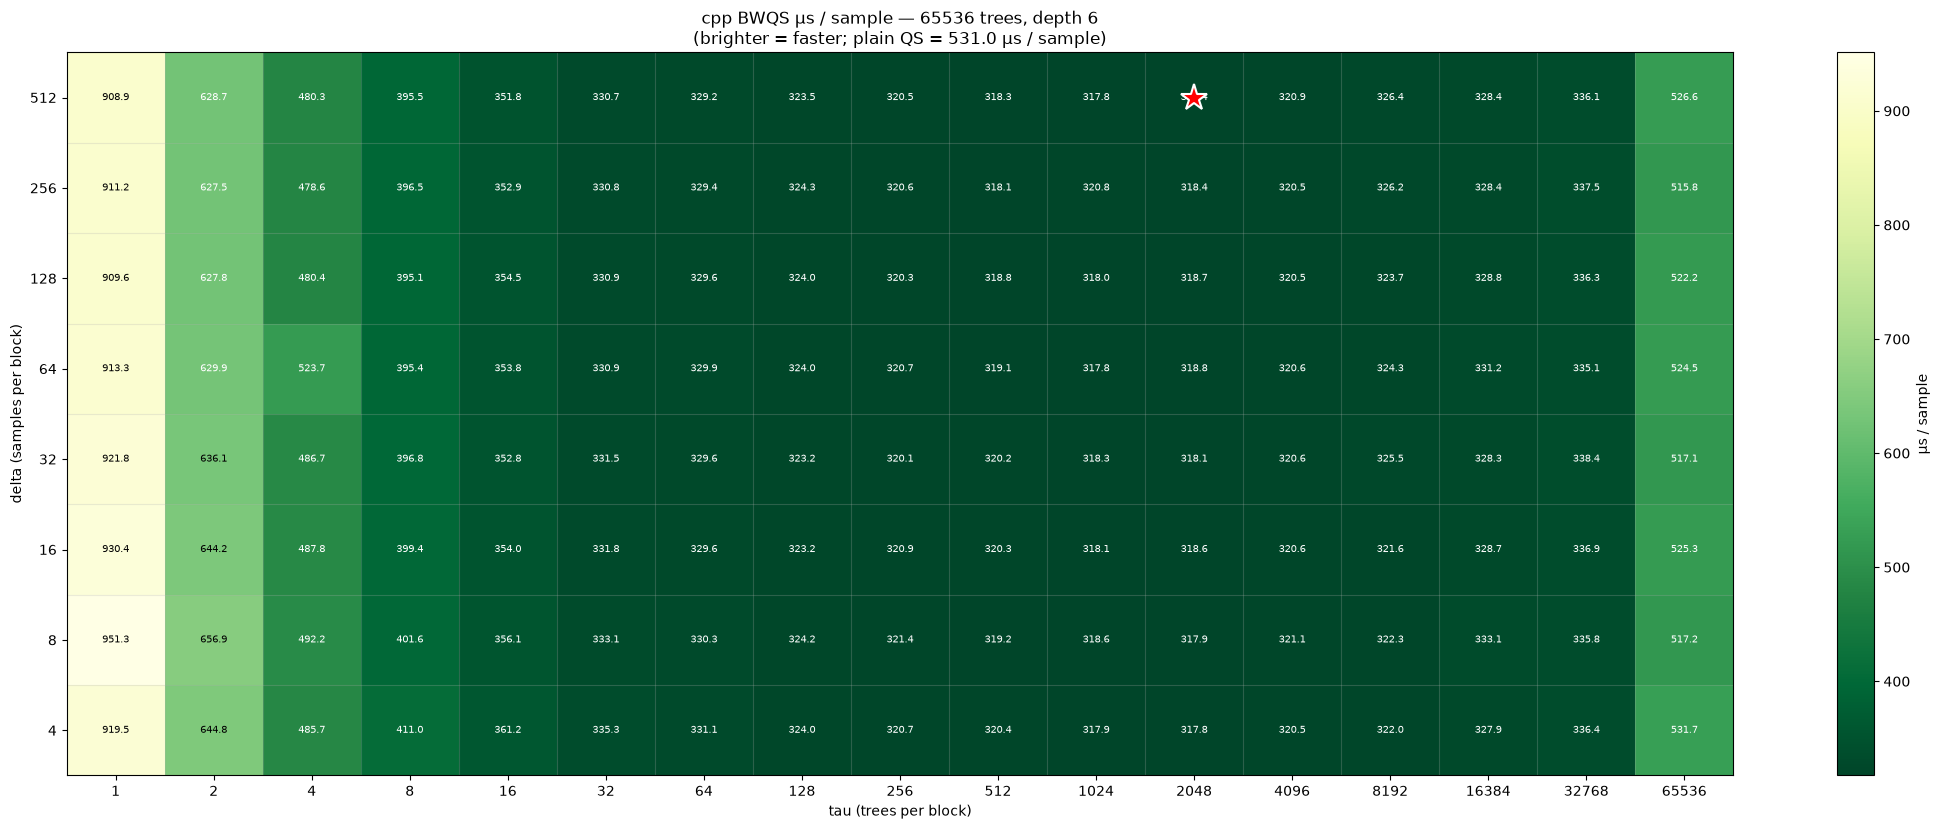

In [13]:
fig, ax = plt.subplots(figsize=(1.1 * len(TAUS) + 3, 0.8 * len(DELTAS) + 2))
im = ax.imshow(grid.T, origin='lower', aspect='auto', cmap='YlGn_r', interpolation='nearest')
ax.set_xticks(range(len(TAUS)))
ax.set_xticklabels([str(v) for v in TAUS])
ax.set_yticks(range(len(DELTAS)))
ax.set_yticklabels([str(v) for v in DELTAS])
ax.set_xlabel('tau (trees per block)')
ax.set_ylabel('delta (samples per block)')
ax.set_title(f'cpp BWQS µs / sample — {HYPEROPT_N} trees, depth {HYPEROPT_DEPTH}\n'
             f'(brighter = faster; plain QS = {qs_baseline:.1f} µs / sample)')

threshold = (grid.min() + grid.max()) / 2
for i in range(len(DELTAS)):
    for j in range(len(TAUS)):
        color = 'white' if grid[j, i] < threshold else 'black'
        ax.text(j, i, f'{grid[j, i]:.1f}', ha='center', va='center',
                fontsize=7, fontweight='medium', color=color)

ax.set_xticks([x - 0.5 for x in range(1, len(TAUS))], minor=True)
ax.set_yticks([y - 0.5 for y in range(1, len(DELTAS))], minor=True)
ax.grid(which='minor', linewidth=0.8, alpha=0.25)
ax.tick_params(which='minor', bottom=False, left=False)

ax.plot(bi, bj, marker='*', color='red', markersize=20,
        markeredgecolor='white', markeredgewidth=1.5, linestyle='none', zorder=5)

fig.colorbar(im, ax=ax, label='µs / sample')
fig.tight_layout()
out = os.path.join(OUTPUT_DIR, 'quickscorer_benchmark_bwqs_heatmap.png')
fig.savefig(out, dpi=200, bbox_inches='tight')
print(f'wrote {out}')

### One knob at a time, through the best point

wrote /home/theayos/code/OPL/bdt-aie-openlab/conifer/examples/quickscorer_benchmark_bwqs_slices.png


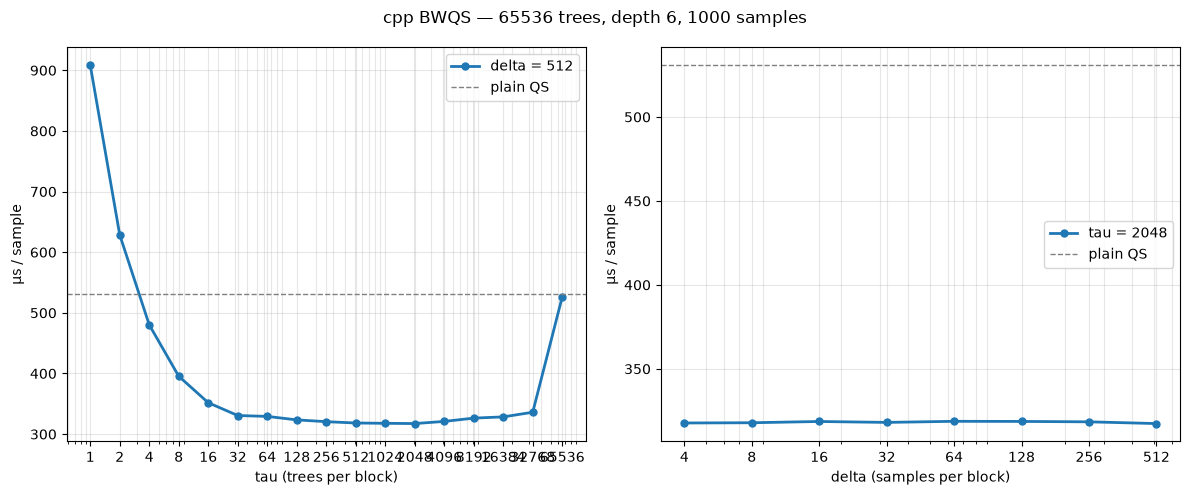

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, values, ys, name, fixed in [
        (axes[0], TAUS, grid[:, bj], 'tau (trees per block)', f'delta = {best_delta}'),
        (axes[1], DELTAS, grid[bi, :], 'delta (samples per block)', f'tau = {best_tau}')]:
    ax.plot(values, ys, marker='o', linewidth=2, markersize=5, label=fixed)
    ax.axhline(qs_baseline, color='grey', linestyle='--', linewidth=1, label='plain QS')
    ax.set_xscale('log')
    ax.set_xticks(values)
    ax.get_xaxis().set_major_formatter(matplotlib.ticker.ScalarFormatter())
    ax.get_xaxis().set_minor_formatter(matplotlib.ticker.NullFormatter())
    ax.set_xlabel(name)
    ax.set_ylabel('µs / sample')
    ax.grid(True, which='both', alpha=0.3)
    ax.legend()
fig.suptitle(f'cpp BWQS — {HYPEROPT_N} trees, depth {HYPEROPT_DEPTH}, {N_SAMPLES} samples')
fig.tight_layout()
out = os.path.join(OUTPUT_DIR, 'quickscorer_benchmark_bwqs_slices.png')
fig.savefig(out, dpi=200, bbox_inches='tight')
print(f'wrote {out}')

In [15]:
hyperopt = pd.DataFrame(
    [('us_per_sample', HYPEROPT_DEPTH, HYPEROPT_N, TAUS[i], DELTAS[j], grid[i, j])
     for i in range(len(TAUS)) for j in range(len(DELTAS))],
    columns=['metric', 'depth', 'n_trees', 'tau', 'delta', 'value'])
hyperopt.attrs['params'] = {
    'qs_baseline_us': float(qs_baseline), 'best_tau': int(best_tau),
    'best_delta': int(best_delta), 'best_us': float(best_us),
    'n_samples': N_SAMPLES, 'precision': PRECISION, 'stamp': stamp,
}
out = os.path.join(OUTPUT_DIR, 'quickscorer_benchmark_bwqs_grid.csv')
hyperopt.to_csv(out, index=False)
print(f'wrote {out} ({len(hyperopt)} rows), params: {hyperopt.attrs["params"]}')
hyperopt

wrote /home/theayos/code/OPL/bdt-aie-openlab/conifer/examples/quickscorer_benchmark_bwqs_grid.csv (136 rows), params: {'qs_baseline_us': 530.9942770109046, 'best_tau': 2048, 'best_delta': 512, 'best_us': 317.41270900238305, 'n_samples': 1000, 'precision': 'ap_fixed<18,8>', 'stamp': 1787601695}


,metric,depth,n_trees,tau,delta,value
0,us_per_sample,6,65536,1,4,919.518660
1,us_per_sample,6,65536,1,8,951.315101
2,us_per_sample,6,65536,1,16,930.409845
3,us_per_sample,6,65536,1,32,921.833507
4,us_per_sample,6,65536,1,64,913.322679
...,...,...,...,...,...,...
131,us_per_sample,6,65536,65536,32,517.128957
132,us_per_sample,6,65536,65536,64,524.534683
133,us_per_sample,6,65536,65536,128,522.219596
134,us_per_sample,6,65536,65536,256,515.844997
